# 第四階段:把 separation 推廣到整場比賽

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:把第三階段「單一 play 的 separation 計算」**批次化**,套用到整場比賽的**每一個傳球 play**,然後開始累積統計(例如每位接球員平均有多空)。

這一階段的關鍵不是新公式,而是**把方法安全地放大**:整場有些 play 不是傳球(跑球、擒殺),程式要能自動辨認並跳過,不能整個壞掉。

---

### 這一階段的原則(跟前面一樣)

- **先用資料算、再下結論**。只累積距離統計,不評論球員好壞。
- 計算公式完全沿用第三階段(歐氏距離、最近防守者),差別只在「從一個 play 變成一整場」。
- 一樣只用這一場比賽(`SAMPLE_GAME_ID`),把批次方法走通,之後才考慮多場。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:`pandas`、`numpy`、`matplotlib`、路徑設定
- **目的**:準備工具,跟前幾階段一樣。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型(macOS 內建),避免圖上中文顯示成方框
plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

print("gameId:", SAMPLE_GAME_ID)

gameId: 2021090900


## 步驟 1:載入整場資料(只讀一次)

- **輸入**:`plays.csv`、`players.csv`、`pffScoutingData.csv`、整場 `tracking`
- **輸出**:四個 DataFrame
- **目的**:整場的檔案只讀一次,後面在記憶體裡反覆篩選,避免重複讀硬碟。

> `pff` 和 `plays` 是全季的,這裡**先篩成只剩這一場**,後面處理比較快。

In [2]:
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

# 先全部篩成這一場
game_plays = plays[plays["gameId"] == SAMPLE_GAME_ID].copy()
game_pff = pff[pff["gameId"] == SAMPLE_GAME_ID].copy()

# nflId -> 人名、位置 的對照表(算完再接,迴圈裡用編號比較快)
id_to_name = players.set_index("nflId")["displayName"].to_dict()

all_play_ids = sorted(tracking["playId"].unique())
print("整場 tracking 裡的 play 數:", len(all_play_ids))
print("tracking 形狀:", tracking.shape)

整場 tracking 裡的 play 數: 97
tracking 形狀: (92644, 16)


## 步驟 2:把「單一 play 的 separation」包成一個函式

- **輸入**:一個 `playId`
- **輸出**:這個 play 每位接球員、每個 frame 的 separation(DataFrame);**若不是傳球 play 就回傳 None**
- **目的**:這是本階段的核心工程。把第三階段的計算包成一個可重複呼叫的函式,並**加上安全檢查**:
  - 沒有 `ball_snap` 或 `pass_forward` → 不是(完整的)傳球 play,回傳 `None` 跳過。
  - 沒有接球員或防守者 → 無法算 separation,回傳 `None`。

計算本身跟第三階段**完全一樣**:每個 frame,每位接球員到最近防守者的歐氏距離。

In [3]:
def separation_for_play(play_id):
    """算單一 play 的 separation。不是傳球 play 就回傳 None。"""
    p = tracking[tracking["playId"] == play_id]

    # 安全檢查 1:要同時有 snap 與 pass_forward
    snap_rows = p.loc[p["event"] == "ball_snap", "frameId"]
    pass_rows = p.loc[p["event"] == "pass_forward", "frameId"]
    if snap_rows.empty or pass_rows.empty:
        return None
    snap_frame = snap_rows.iloc[0]
    pass_frame = pass_rows.iloc[0]

    # 這個 play 的角色對照(nflId -> role)
    roles = game_pff[game_pff["playId"] == play_id].set_index("nflId")["pff_role"]
    receiver_ids = set(roles[roles == "Pass Route"].index)
    defender_ids = set(roles[roles == "Coverage"].index)

    # 安全檢查 2:要有接球員也要有防守者
    if not receiver_ids or not defender_ids:
        return None

    # 切 snap -> pass 片段
    seg = p[(p["frameId"] >= snap_frame) & (p["frameId"] <= pass_frame)]

    rows = []
    for frame_id, fg in seg.groupby("frameId"):
        rec_f = fg[fg["nflId"].isin(receiver_ids)]
        def_f = fg[fg["nflId"].isin(defender_ids)]
        if rec_f.empty or def_f.empty:
            continue
        def_xy = def_f[["x", "y"]].to_numpy()
        for _, r in rec_f.iterrows():
            dists = np.sqrt((def_xy[:, 0] - r["x"]) ** 2 + (def_xy[:, 1] - r["y"]) ** 2)
            rows.append({
                "playId": play_id,
                "frameId": frame_id,
                "is_pass_frame": frame_id == pass_frame,
                "receiver_id": r["nflId"],
                "separation_yd": round(float(dists.min()), 2),
            })
    return pd.DataFrame(rows) if rows else None


# 先拿第三階段那個 play 測一下,確認結果一致
test = separation_for_play(137)
print("playId=137 的 separation 形狀:", None if test is None else test.shape)
test.head() if test is not None else "無結果"

playId=137 的 separation 形狀: (130, 5)


,playId,frameId,is_pass_frame,receiver_id,separation_yd
0,137,7,False,42347.0,6.34
1,137,7,False,43293.0,11.25
2,137,7,False,45532.0,5.47
3,137,7,False,46206.0,5.05
4,137,7,False,52425.0,4.00


## 步驟 3:跑完整場的每一個 play

- **輸入**:`all_play_ids`
- **輸出**:`all_sep`(整場所有傳球 play 的 separation 疊在一起)、`skipped`(被跳過的 play)
- **目的**:對整場每個 play 呼叫上面的函式,把傳球 play 的結果收集起來,非傳球 play 記下來跳過。

In [4]:
results = []
skipped = []
for pid in all_play_ids:
    out = separation_for_play(pid)
    if out is None:
        skipped.append(pid)
    else:
        results.append(out)

all_sep = pd.concat(results, ignore_index=True)

print("成功計算的傳球 play 數:", len(results))
print("跳過的 play 數(非傳球/資料不全):", len(skipped))
print("跳過的 playId:", skipped)
print("\nall_sep 總列數:", len(all_sep))
all_sep.head()

成功計算的傳球 play 數: 92
跳過的 play 數(非傳球/資料不全): 5
跳過的 playId: [np.int64(788), np.int64(925), np.int64(2279), np.int64(2298), np.int64(2330)]

all_sep 總列數: 12164


,playId,frameId,is_pass_frame,receiver_id,separation_yd
0,97,6,False,35481.0,3.03
1,97,6,False,35634.0,2.71
2,97,6,False,39985.0,8.63
3,97,6,False,41233.0,1.38
4,97,6,False,44896.0,4.28


## 步驟 4:每位接球員「傳球瞬間」的平均 separation

- **輸入**:`all_sep`
- **輸出**:每位接球員的統計表 `player_stats`
- **目的**:只看每個 play **傳球當下(pass_forward)** 的 separation,統計每位接球員整場下來平均有多空、被瞄準過幾次。

> 「平均 separation」是把這位球員在不同 play 傳球瞬間的空檔平均起來。數字高只代表「這些 play 他平均比較空」,不直接等於能力好壞。

In [5]:
# 只取傳球瞬間那一格
at_pass = all_sep[all_sep["is_pass_frame"]].copy()

player_stats = (
    at_pass.groupby("receiver_id")
    .agg(plays_as_route=("playId", "nunique"),
         avg_separation_yd=("separation_yd", "mean"),
         min_separation_yd=("separation_yd", "min"),
         max_separation_yd=("separation_yd", "max"))
    .reset_index()
)
player_stats["receiver"] = player_stats["receiver_id"].map(id_to_name)
player_stats = player_stats.round(2)

# 只看跑過至少 5 個路線的人,平均才有意義;依平均 separation 排序
top = player_stats[player_stats["plays_as_route"] >= 5].sort_values(
    "avg_separation_yd", ascending=False
)
print("=== 傳球瞬間平均 separation(至少跑 5 條路線的接球員)===")
print(top[["receiver", "plays_as_route", "avg_separation_yd",
           "min_separation_yd", "max_separation_yd"]].to_string(index=False))

=== 傳球瞬間平均 separation(至少跑 5 條路線的接球員)===
         receiver  plays_as_route  avg_separation_yd  min_separation_yd  max_separation_yd
  Ezekiel Elliott              32               6.54               1.59              16.88
Leonard Fournette              23               5.50               1.40              14.32
  Giovani Bernard              14               5.19               0.47              10.80
     Tony Pollard               7               4.80               1.03               6.86
   Cedrick Wilson              19               3.63               0.60               6.92
     Blake Jarwin              29               3.42               0.81               9.90
     Amari Cooper              44               3.40               0.69               8.46
   Rob Gronkowski              32               3.36               0.75              14.17
    Antonio Brown              33               3.09               0.55              13.67
      CeeDee Lamb              41               3.

## 步驟 5:整場 separation 的整體分佈

- **輸入**:`at_pass`(所有傳球 play、傳球瞬間的 separation)
- **輸出**:一張直方圖
- **目的**:整場比賽裡,「傳球瞬間接球員跟最近防守者的距離」大概長怎樣?大多數傳球是在多大的空檔下出手的?

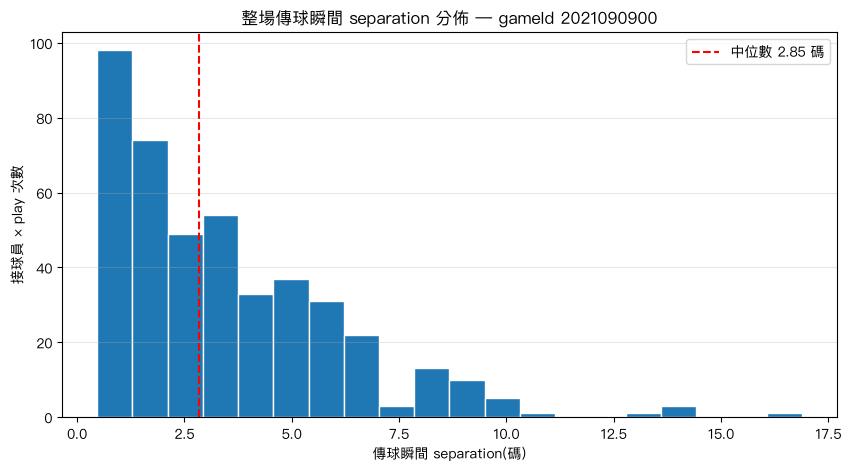

樣本數(接球員×play): 435
平均: 3.47 碼 / 中位數: 2.85 碼
最小: 0.47 碼 / 最大: 16.88 碼


In [6]:
vals = at_pass["separation_yd"]
median = vals.median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vals, bins=20, color="tab:blue", edgecolor="white")
ax.axvline(median, color="red", linestyle="--", linewidth=1.5,
           label=f"中位數 {median:.2f} 碼")
ax.set_xlabel("傳球瞬間 separation(碼)")
ax.set_ylabel("接球員 × play 次數")
ax.set_title(f"整場傳球瞬間 separation 分佈 — gameId {SAMPLE_GAME_ID}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

print("樣本數(接球員×play):", len(vals))
print("平均:", round(vals.mean(), 2), "碼 / 中位數:", round(median, 2), "碼")
print("最小:", round(vals.min(), 2), "碼 / 最大:", round(vals.max(), 2), "碼")

## 本階段完成了什麼

- 把第三階段的 separation 計算包成函式 `separation_for_play()`,並加上安全檢查。
- 對整場每個 play 批次執行:自動辨認並跳過非傳球 play,只統計傳球 play。
- 彙整每位接球員傳球瞬間的平均 separation(被瞄準次數、平均/最小/最大)。
- 畫出整場傳球瞬間 separation 的分佈直方圖,看出大多數傳球的空檔落在哪個範圍。

**下一階段(等你確認理解後再開始)**:兩條路可選 ——
1. **再放大到多場**:把整場的批次方法套到多個 `gameId`,累積跨場統計(需逐場讀對應的 tracking 檔)。
2. **升級空間指標**:改用控制區(Voronoi)描述「整片場地分別被誰控制」,比「最近防守者距離」更完整地回答空間歸屬。